In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

# plt.rcParams['figure.facecolor'] = 'black'
# plt.rcParams['axes.facecolor'] = 'black'
# plt.rcParams['axes.edgecolor'] = 'white'
# plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['xtick.color'] = 'white'
# plt.rcParams['ytick.color'] = 'white'
# plt.rcParams['text.color'] = 'white'
# plt.rcParams['grid.color'] = 'white'

pathfile=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

addtotitle='_112025_42s' # to specify the version of the data

Aging_INDICES = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

DTI=np.zeros((42, 98, 7))  # 10 DTI metrics
for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_FA{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC



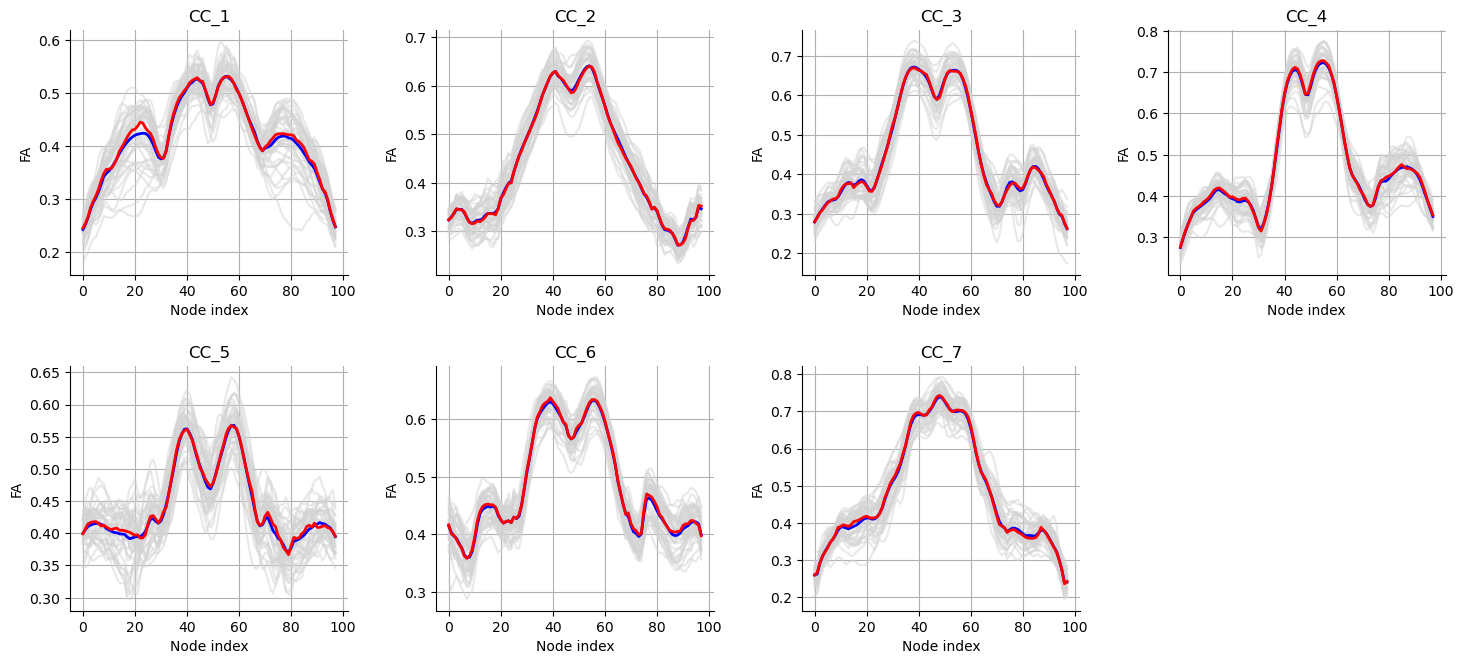

In [3]:
CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel('FA')
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)
    
fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)



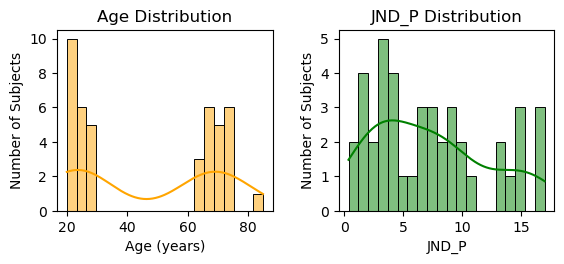

In [4]:
 # target var

import seaborn as sns

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
plt.tight_layout(pad=2.0)
plt.show()


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, learning_curve
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, SelectFromModel
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.pipeline import Pipeline

labels = [0,1]
Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values
age_grouped = Aging_INDICES['group_O']
jnd_grouped = Aging_INDICES['JND_group']

Aging_INDICES



,sub,age,group,JND_P,group_O,group_Y,JND_group
0,sub-01,25,Y,9.5600,0.0,1.0,1
1,sub-02,27,Y,6.6900,0.0,1.0,0
2,sub-03,28,Y,12.9200,0.0,1.0,1
3,sub-05,21,Y,1.9500,0.0,1.0,0
4,sub-06,25,Y,2.5400,0.0,1.0,0
5,sub-08,67,O,4.4800,1.0,0.0,0
6,sub-09,73,O,9.6300,1.0,0.0,1
7,sub-10,64,O,7.2700,1.0,0.0,1
8,sub-11,21,Y,1.6200,0.0,1.0,0
9,sub-12,21,Y,3.6800,0.0,1.0,0


RIDGE REGRESSION


CC1 Best features (importance > 80% max): [74 75 76 77 78 79 81 82 83 84 85 86]
CC2 Best features (importance > 80% max): [ 7  9 12 13 68 69 70 71 72 73 74 75 76]
CC3 Best features (importance > 80% max): [12 13 14 22 23 79]
CC4 Best features (importance > 80% max): [45 47 54 55 56 69 70 77 78 79 80 81 82 83]
CC5 Best features (importance > 80% max): [15 16 17 18 19 42 59 60 73 74]
CC6 Best features (importance > 80% max): [52 75 82 84 85 86 87 88]
CC7 Best features (importance > 80% max): [ 1 26 65 72 83]


[array([74, 75, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86]),
 array([ 7,  9, 12, 13, 68, 69, 70, 71, 72, 73, 74, 75, 76]),
 array([12, 13, 14, 22, 23, 79]),
 array([45, 47, 54, 55, 56, 69, 70, 77, 78, 79, 80, 81, 82, 83]),
 array([15, 16, 17, 18, 19, 42, 59, 60, 73, 74]),
 array([52, 75, 82, 84, 85, 86, 87, 88]),
 array([ 1, 26, 65, 72, 83])]

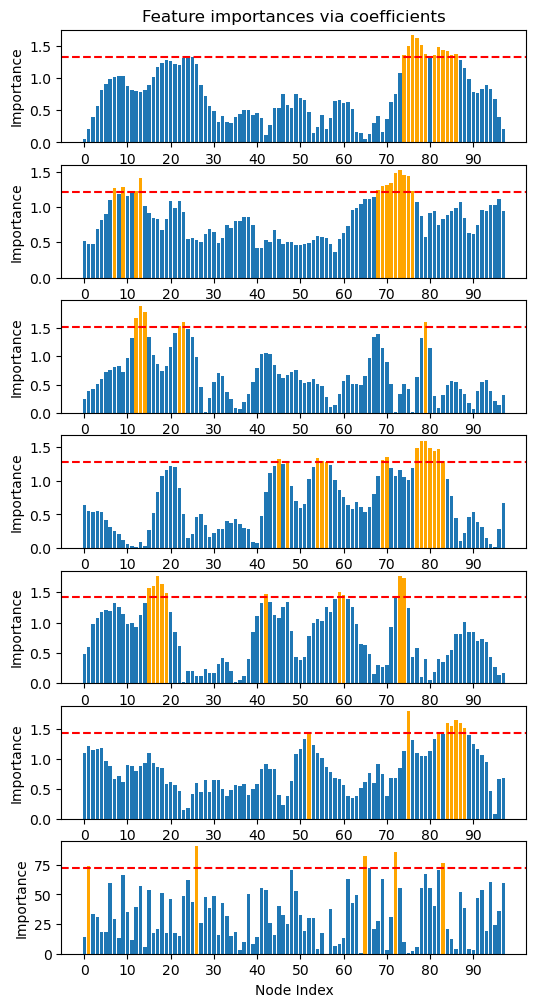

In [6]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import RidgeCV

thresholdpercent = 0.80

y=jnd       # Target (dependent variable)

figure, axs = plt.subplots(7, 1, figsize=(6,12))
best_features_all_ridge = []
for cc in range(7):
    X=DTI[:,:,cc]  # Features (independent variable)

    feature_names=np.array([f'{i}' for i in range(98)])
    feature=np.arange(98)

    ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X, y)
    importance = np.abs(ridge.coef_)
    ax = axs[cc]
    ax.bar(height=importance, x=feature_names)
    ax.set_xticks(range(0,98,10))
    ax.axhline(np.max(importance)*thresholdpercent, color='red', linestyle='--')
    ax.set_xlabel('Node Index')
    ax.set_ylabel('Importance')

    threshold = np.max(importance)*thresholdpercent

    importance_plus=np.where(importance>threshold)
    ax.bar(height=importance[importance_plus], x=feature_names[importance_plus], color='orange')

    best_features = feature[importance > threshold]
    print(f'CC{cc+1} Best features (importance > {int(thresholdpercent*100)}% max): {best_features}')
    best_features_all_ridge.append(best_features)
axs[0].set_title("Feature importances via coefficients")



best_features_all_ridge


Processing target age CC 1
RandomForestRegressor for Age
Processing target age CC 2
RandomForestRegressor for Age
Processing target age CC 3
RandomForestRegressor for Age
Processing target age CC 4
RandomForestRegressor for Age
Processing target age CC 5
RandomForestRegressor for Age
Processing target age CC 6
RandomForestRegressor for Age
Processing target age CC 7
RandomForestRegressor for Age
Processing target jnd CC 1
SVR linear for JND
Processing target jnd CC 2
SVR linear for JND
Processing target jnd CC 3
SVR linear for JND
Processing target jnd CC 4
SVR linear for JND
Processing target jnd CC 5
SVR linear for JND
Processing target jnd CC 6
SVR linear for JND
Processing target jnd CC 7
SVR linear for JND


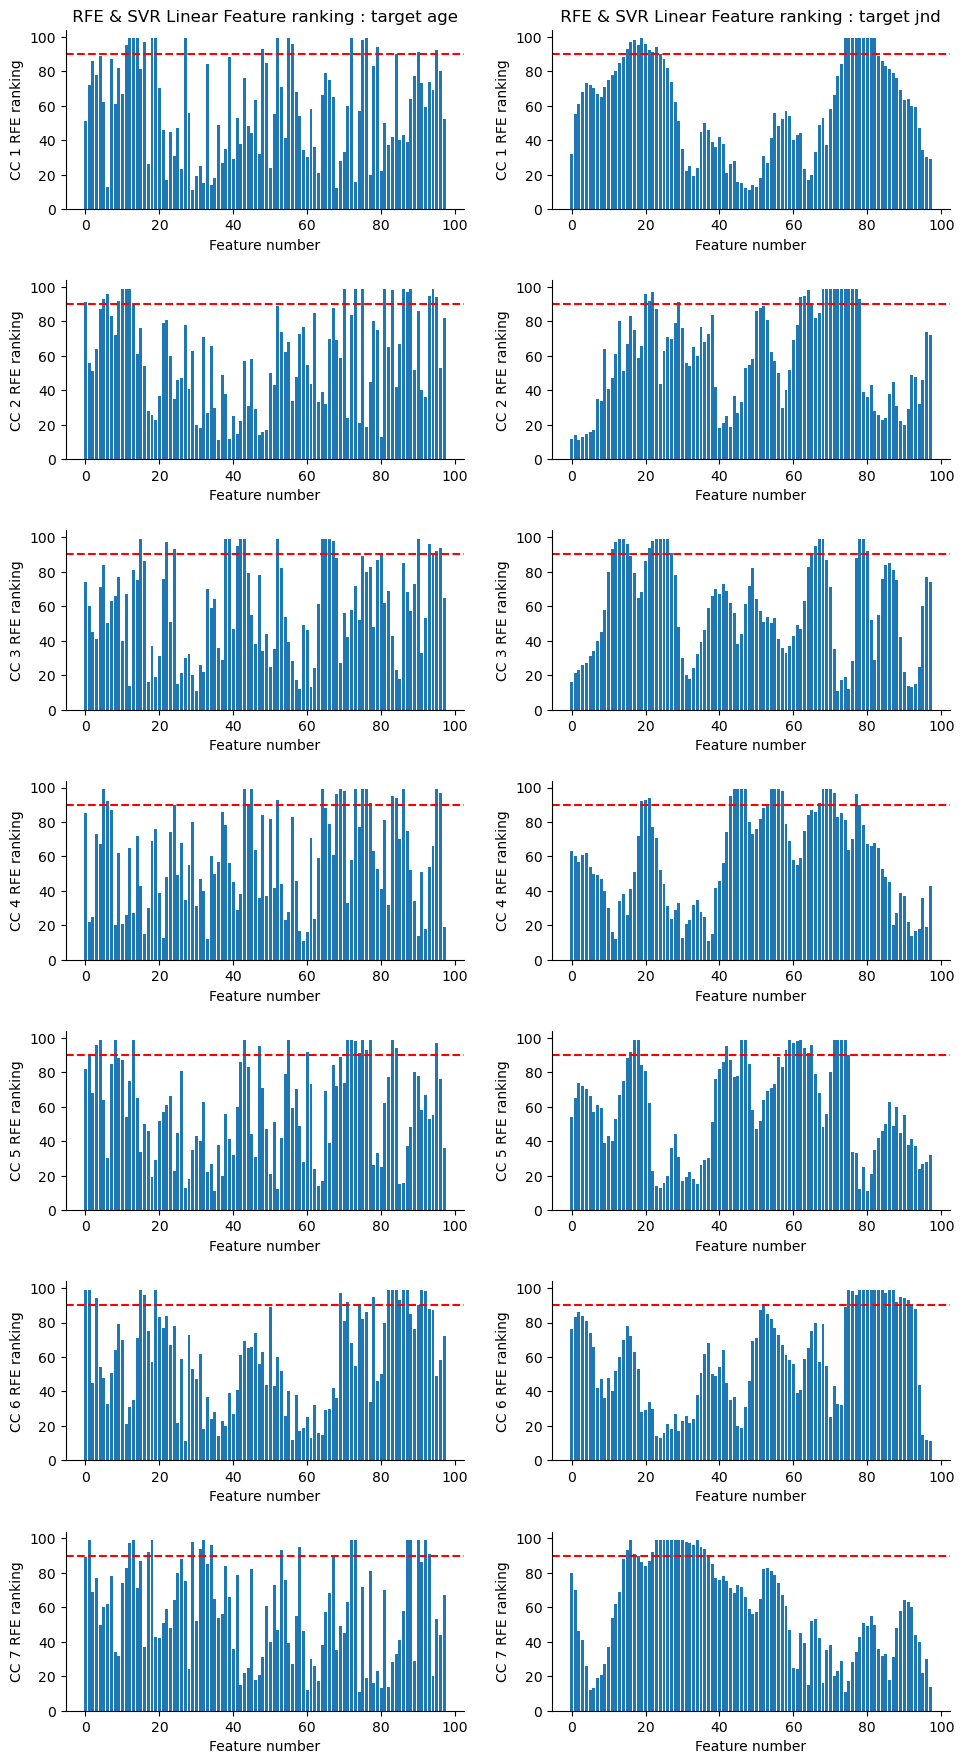

In [14]:
from sklearn.datasets import make_friedman1
from sklearn.feature_selection import RFE
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

random_state=np.random.randint(0,100)


target=['age', 'jnd']
figure, axs = plt.subplots(nrows=7, ncols=2, figsize=(10, 18))

ranked_feat_allCC_tgt=[]

for t in target:
    if t=='age':
        y=age
        axsy=0
    elif t=='jnd':
        y=jnd
        axsy=1
    ranked_feat_allCC=[]
    
    for cc in range(7):
        print(f'Processing target {t} CC {cc+1}')
        X=DTI[:,:,cc]     # Features (independent variable)
            
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        if t=='jnd':
            estimator = SVR(kernel="linear")
            print('SVR linear for JND')
        elif t=='age':
            estimator = RandomForestRegressor(n_estimators=100, random_state=42)
            print('RandomForestRegressor for Age')

        selector = RFE(estimator, n_features_to_select=10, step=1)
        selector = selector.fit(X_train, y_train)
        selector.support_
        selector.ranking_
        ranked_feat_allCC.append(selector.ranking_)

        np.where(selector.ranking_<10)[0].tolist()
        axs[cc, axsy].bar(np.arange(98), 100-selector.ranking_)
        axs[cc, axsy].axhline(90, color='red', linestyle='--')  
        axs[cc, axsy].set_xlabel("Feature number")
        axs[cc, axsy].set_ylabel(f'CC {cc+1} RFE ranking') 
        axs[cc, axsy].spines['top'].set_visible(False)
        axs[cc, axsy].spines['right'].set_visible(False)

    axs[0, axsy].set_title(f' RFE & SVR Linear Feature ranking : target {t} ')
    plt.tight_layout(pad=2.0)

    ranked_feat_allCC_tgt.append(ranked_feat_allCC)



In [19]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import random
from scipy.stats import ttest_ind


nseeds=100
random_numbers = [random.randint(0, 100) for _ in range(nseeds)]

MSE_cc_all_alltgt_featandtgt=[]
R_squareds_cc_all_alltgt_featandtgt=[]
MAE_cc_all_alltgt_featandtgt=[]

for target in ['age','jnd']:
    print("Target:", target)
    MAE_cc_all_alltgt=[]
    R_squareds_cc_all_alltgt=[]
    MSE_cc_all_alltgt=[]

    if target=='age':
        y=age       
    elif target=='jnd':
        y=jnd       

    for featSelectedOn in ['age','jnd']:
        print("Feature selection on:", featSelectedOn)
        if featSelectedOn=='age':
            SelectedFeat=ranked_feat_allCC_tgt[0]
        elif featSelectedOn=='jnd':
            SelectedFeat=ranked_feat_allCC_tgt[1]
                            
        MAE_cc_all=[]
        R_squareds_cc_all=[]
        MSE_cc_all=[]

        for cc in [0,1,2,3,4,5,6]:  #### CHOOSE CC6 ONLY
            print("CC:", cc+1)
            MAE_cc=[]
            R_squareds_cc=[]
            MSE_cc=[]
            for seed in range(nseeds):
                random_state=random_numbers[seed]
                select_feature=np.where(SelectedFeat[cc]<5)

                X=DTI[:,select_feature[0].tolist(),cc]    

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                    # Target (dependent variable)
            # Train classifiers
                reg1 = GradientBoostingRegressor(random_state=1)
                # reg2 = RandomForestRegressor(random_state=1)

                if target=='age':
                    reg3 = LinearRegression()
                elif target=='jnd':
                    reg3 = LinearRegression()

                reg1.fit(X_train_scaled, y_train)
                # reg2.fit(X_train_scaled, y_train)
                # reg3.fit(X_train_scaled, y_train)

                ereg = VotingRegressor([("gb", reg1)]) #, ("rf", reg2), ("lr", reg3)])
                ereg.fit(X_train_scaled, y_train)

                pred1 = reg1.predict(X_test_scaled)
                # pred2 = reg2.predict(X_test_scaled)
                # pred3 = reg3.predict(X_test_scaled)
                pred4 = ereg.predict(X_test_scaled)
                # print("r2_score:", r2_score(y_test, pred4))
                MAE_cc.append(mean_absolute_error(y_test, pred4))
                R_squareds_cc.append(r2_score(y_test, pred4))
                MSE_cc.append(mean_squared_error(y_test, pred4))

                # print("MAE:", mean_absolute_error(y_test, pred4))

            MAE_cc_all.append(MAE_cc)
            R_squareds_cc_all.append(R_squareds_cc)
            MSE_cc_all.append(MSE_cc)

        MAE_cc_all_alltgt.append(MAE_cc_all)
        R_squareds_cc_all_alltgt.append(R_squareds_cc_all)
        MSE_cc_all_alltgt.append(MSE_cc_all)

    MSE_cc_all_alltgt_featandtgt.append(MSE_cc_all_alltgt)
    R_squareds_cc_all_alltgt_featandtgt.append(R_squareds_cc_all_alltgt)
    MAE_cc_all_alltgt_featandtgt.append(MAE_cc_all_alltgt)
    #####

np.savez(f'only cc all {nseeds} seeds ok from New RFE.npz',random_numbers=random_numbers,MAE_cc_all_alltgt_featandtgt=MAE_cc_all_alltgt_featandtgt,R_squareds_cc_all_alltgt_featandtgt=R_squareds_cc_all_alltgt_featandtgt,MSE_cc_all_alltgt_featandtgt=MSE_cc_all_alltgt_featandtgt)


Target: age
Feature selection on: age
CC: 1
CC: 2
CC: 3
CC: 4
CC: 5
CC: 6
CC: 7
Feature selection on: jnd
CC: 1
CC: 2
CC: 3
CC: 4
CC: 5
CC: 6
CC: 7
Target: jnd
Feature selection on: age
CC: 1
CC: 2
CC: 3
CC: 4
CC: 5
CC: 6
CC: 7
Feature selection on: jnd
CC: 1
CC: 2
CC: 3
CC: 4
CC: 5
CC: 6
CC: 7


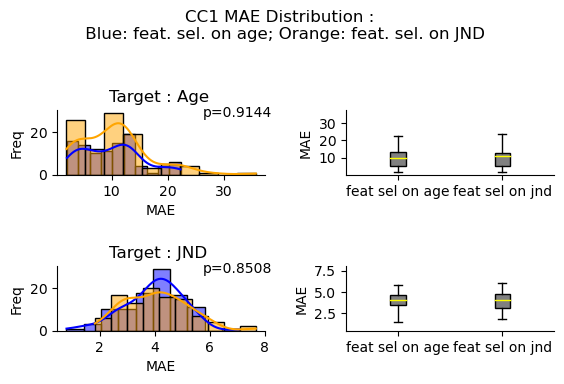

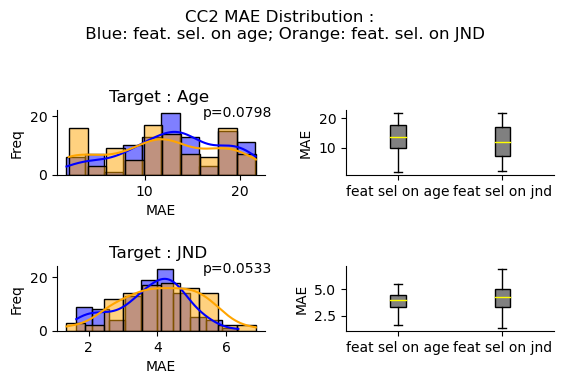

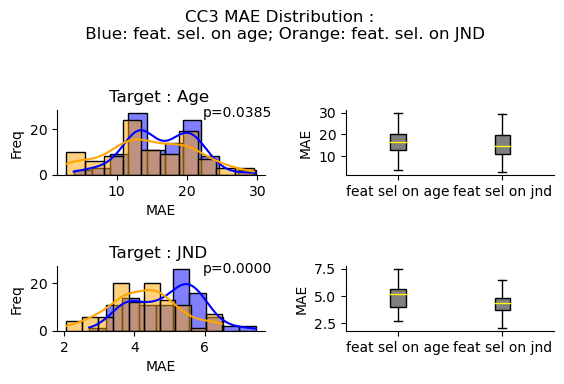

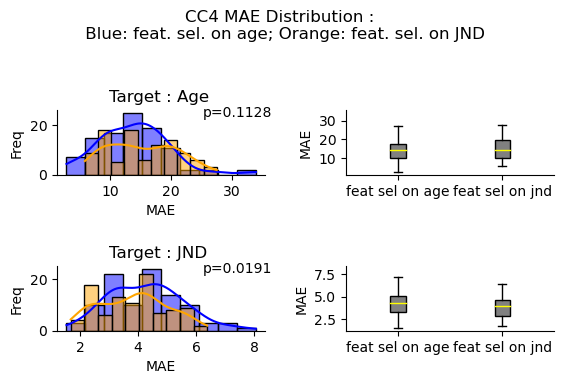

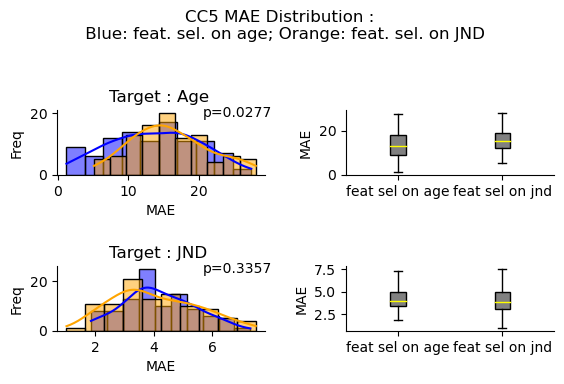

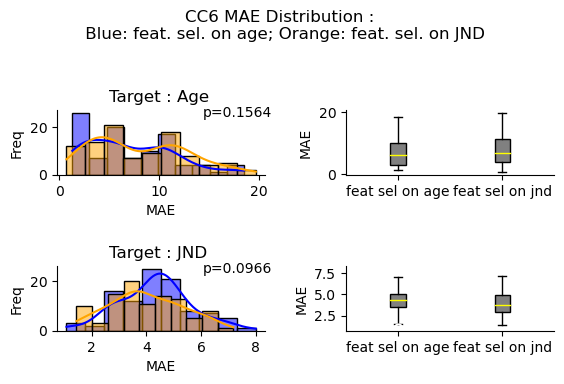

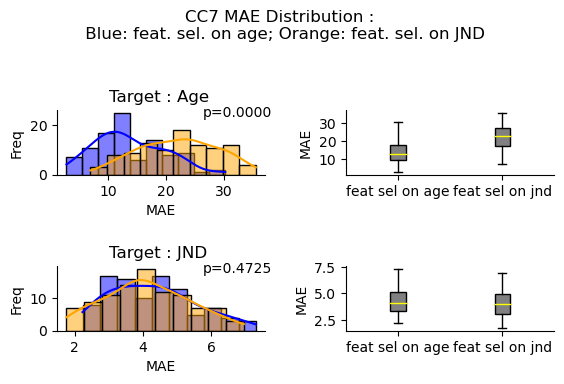

In [32]:

VarToTest=[MAE_cc_all_alltgt_featandtgt, MSE_cc_all_alltgt_featandtgt, R_squareds_cc_all_alltgt_featandtgt]
VarToTestNameList=['MAE', 'MSE', 'R squared']

VarToTest=MAE_cc_all_alltgt_featandtgt
VarToTestName='MAE'

CClist=[0,1,2,3,4,5,6]

for ccidx ,cc in enumerate(CClist):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(6, 4))
    
    for i, target in enumerate(['Age','JND']):

        if target=='Age':
            index=0
        elif target=='JND':
            index=1

        from scipy.stats import kruskal

        kruskal_stat, kruskal_p = kruskal(VarToTest[index][0][ccidx], VarToTest[index][1][ccidx])
        sns.histplot(VarToTest[index][0][ccidx], bins=10, kde=True, color='blue',ax=ax[i,0])
        sns.histplot(VarToTest[index][1][ccidx], bins=10, kde=True, color='orange',ax=ax[i,0])
        ax[i,0].text(0.7, 0.9, f'p={kruskal_p:.4f}', transform=ax[i,0].transAxes, color='black')
        ax[i,0].set_ylabel('Freq')
        ax[i,0].grid(False)
        ax[i,0].spines['top'].set_visible(False)
        ax[i,0].spines['right'].set_visible(False)
        ax[i,0].set_title(f'Target : {target} ')

        ax[i,1].boxplot([ VarToTest[index][0][ccidx], VarToTest[index][1][ccidx]], labels=['feat sel on age', 'feat sel on jnd'], patch_artist=True,
                        boxprops=dict(facecolor='grey', color='black'),
                        medianprops=dict(color='yellow'),
                        whiskerprops=dict(color='black'),
                        capprops=dict(color='black'),
                        flierprops=dict(color='black', markeredgecolor='white'))
        ax[i,1].set_ylabel(VarToTestName)
        ax[i,1].grid(False)
        ax[i,1].spines['top'].set_visible(False)
        ax[i,1].spines['right'].set_visible(False)


        ax[i,0].set_xlabel(VarToTestName)

        fig.suptitle(f'CC{cc+1} {VarToTestName} Distribution : \n Blue: feat. sel. on age; Orange: feat. sel. on JND' )
    plt.tight_layout(pad=2.0 )
    plt.show()

Text(0, 0.5, 'MAE')

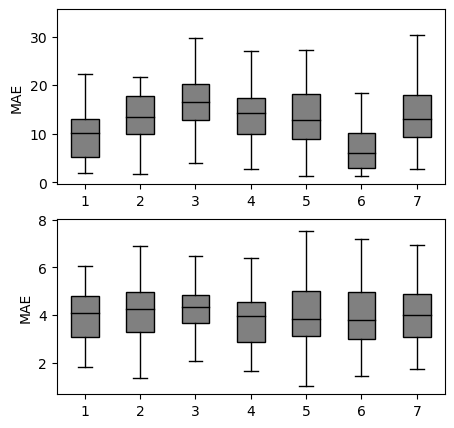

In [ ]:
MAE_cc_all_alltgt_featandtgt[0][0]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(5, 5))
datatoplot=MAE_cc_all_alltgt_featandtgt[0][0]
ax[0].boxplot([datatoplot[0], datatoplot[1],datatoplot[2],datatoplot[3],datatoplot[4],datatoplot[5],datatoplot[6]], patch_artist=True,
            boxprops=dict(facecolor='grey', color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(color='black', markeredgecolor='white'))
ax[0].set_ylabel('MAE')

datatoplot=MAE_cc_all_alltgt_featandtgt[1][1]
ax[1].boxplot([datatoplot[0], datatoplot[1],datatoplot[2],datatoplot[3],datatoplot[4],datatoplot[5],datatoplot[6]], patch_artist=True,
            boxprops=dict(facecolor='grey', color='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(color='black', markeredgecolor='white'))
ax[1].set_ylabel('MAE')